In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import cohen_kappa_score, f1_score, accuracy_score
from tqdm import tqdm
import os


AR_CSV = "../data/arkansas.csv"
CA_CSV = "../data/california.csv"

# ── Label remapping — CDL codes → 0-based class indices ──
# Arkansas (paper Table 2 order)
AR_REMAP = {5: 0, 3: 1, 1: 2, 2: 3, 0: 4}
AR_CLASSES = ['Soybeans', 'Rice', 'Corn', 'Cotton', 'Others']

# California 
# fatima used code 69 for grapes
CA_REMAP = {69: 0, 3: 1, 36: 2, 75: 3, 204: 4, 0: 5}
CA_CLASSES = ['Grapes', 'Rice', 'Alfalfa', 'Almonds', 'Pistachios', 'Others']


def load_data(csv_path, label_remap, class_names):
    """
    Load data in fatima's format:
    CSV columns: B2_0..B12_35, SCL_0..SCL_35,
                 crop_0..crop_35, mask_0..mask_35, target_label
    Returns X [N,36,10], mask [N,36], labels [N]
    """
    print(f"Loading {csv_path}...")
    df = pd.read_csv(csv_path)
    print(f"  Shape: {df.shape}")
    df.columns = df.columns.str.strip()

    # ── Reshape to (N, 36, 13) ──
    y_raw    = df['target_label'].values
    features = df.drop(columns=['target_label']).values
    data_3d  = features.reshape(-1, 36, 13)  # (N, 36, 13)

    # ── Extract X (10 spectral bands) and mask ──
    X    = data_3d[:, :, :10].astype(np.float32)   # [N, 36, 10]
    mask = data_3d[:, :, 12].astype(np.float32)    # [N, 36]

    # ── Normalize reflectance ──
    # Check if values are in raw DN range (>10) or already normalized
    if X.max() > 10:
        X = X / 10000.0
        print("  Normalized reflectance values by /10000")

    # ── Remap labels ──
    n_classes = len(class_names)
    labels = np.array([label_remap.get(int(l), n_classes-1) for l in y_raw])

    print(f"  X shape:    {X.shape}")
    print(f"  Mask shape: {mask.shape}")
    print(f"  Class distribution:")
    for i, name in enumerate(class_names):
        count = (labels == i).sum()
        pct   = count / len(labels) * 100
        print(f"    {i}: {name:12s} → {count:5,} ({pct:.1f}%)")

    return X, mask, labels


# Load both states
X_ar, mask_ar, y_ar = load_data(AR_CSV, AR_REMAP, AR_CLASSES)
print()
X_ca, mask_ca, y_ca = load_data(CA_CSV, CA_REMAP, CA_CLASSES)

Loading ../data/arkansas.csv...
  Shape: (10000, 469)
  Normalized reflectance values by /10000
  X shape:    (10000, 36, 10)
  Mask shape: (10000, 36)
  Class distribution:
    0: Soybeans     → 4,677 (46.8%)
    1: Rice         → 2,423 (24.2%)
    2: Corn         → 1,522 (15.2%)
    3: Cotton       →   762 (7.6%)
    4: Others       →   616 (6.2%)

Loading ../data/california.csv...
  Shape: (10000, 469)
  Normalized reflectance values by /10000
  X shape:    (10000, 36, 10)
  Mask shape: (10000, 36)
  Class distribution:
    0: Grapes       → 2,054 (20.5%)
    1: Rice         → 2,037 (20.4%)
    2: Alfalfa      →   974 (9.7%)
    3: Almonds      →   783 (7.8%)
    4: Pistachios   →   640 (6.4%)
    5: Others       → 3,512 (35.1%)


In [2]:
def split_paper(X, mask, labels, n_classes,
                n_train=240, n_val=60, seed=42):
    """
    Paper section 2.4:
    300 samples per class → 240 train + 60 val, rest = test
    """
    rng = np.random.RandomState(seed)
    train_idx, val_idx, test_idx = [], [], []

    for c in range(n_classes):
        idx = np.where(labels == c)[0]
        rng.shuffle(idx)

        if len(idx) >= n_train + n_val:
            train_idx.extend(idx[:n_train])
            val_idx.extend(idx[n_train:n_train + n_val])
            test_idx.extend(idx[n_train + n_val:])
        elif len(idx) >= n_train:
            train_idx.extend(idx[:n_train])
            val_idx.extend(idx[n_train:])
        else:
            train_idx.extend(idx)

    return np.array(train_idx), np.array(val_idx), np.array(test_idx)


# Split Arkansas
tr_ar, val_ar, te_ar = split_paper(X_ar, mask_ar, y_ar, 5)
print("Arkansas split:")
print(f"  Train: {len(tr_ar)} | Val: {len(val_ar)} | Test: {len(te_ar)}")

# Split California
tr_ca, val_ca, te_ca = split_paper(X_ca, mask_ca, y_ca, 6)
print("California split:")
print(f"  Train: {len(tr_ca)} | Val: {len(val_ca)} | Test: {len(te_ca)}")

Arkansas split:
  Train: 1200 | Val: 300 | Test: 8500
California split:
  Train: 1440 | Val: 360 | Test: 8200


CELL 3

In [3]:
import math
import torch
import torch.nn as nn

# ─────────────────────────────────────────────────────
# ECA — Efficient Channel Attention (Figure 5)
# ─────────────────────────────────────────────────────
class ECA(nn.Module):
    def __init__(self, kernel_size=3):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.conv     = nn.Conv1d(1, 1, kernel_size=kernel_size,
                                  padding=kernel_size//2, bias=False)
        self.sigmoid  = nn.Sigmoid()

    def forward(self, x):
        # x: [B, T, C]
        y = x.transpose(1, 2)    # [B, C, T]
        y = self.avg_pool(y)     # [B, C, 1]
        y = y.transpose(1, 2)   # [B, 1, C]
        y = self.conv(y)         # [B, 1, C]
        y = self.sigmoid(y)      # [B, 1, C]
        return x * y             # [B, T, C]


# ─────────────────────────────────────────────────────
# ALPE — Attention-based Learnable Positional Encoding
# Paper equation 3: ALPE(t) = ECA(Conv1D(PE(t) × mask))
# Figure 5
# ─────────────────────────────────────────────────────
class ALPE(nn.Module):
    def __init__(self, seq_len, d_model):
        super().__init__()
        self.conv1d = nn.Conv1d(d_model, d_model,
                                kernel_size=3, padding=1, bias=False)
        self.eca    = ECA(kernel_size=3)

        pe       = torch.zeros(seq_len, d_model)
        position = torch.arange(seq_len).float().unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float()
            * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term[:pe[:, 1::2].shape[1]])
        self.register_buffer('pe', pe)  # [T, d_model]

    def forward(self, x, mask):
        """
        x:    [B, T, d_model]
        mask: [B, T]  — 1=valid, 0=missing (Input 2 in paper)
        """
        B = x.shape[0]
        # Step 1: absolute PE → 2D vector
        pe       = self.pe.unsqueeze(0).expand(B, -1, -1)  # [B, T, d_model]
        # Step 2: mask missing positions
        mask_exp = mask.unsqueeze(-1).float()               # [B, T, 1]
        pe_masked = pe * mask_exp                           # [B, T, d_model]
        # Step 3: 1D Conv
        pe_conv = self.conv1d(
            pe_masked.transpose(1, 2)
        ).transpose(1, 2)                                   # [B, T, d_model]
        # Step 4: ECA (Average Pooling + 1D Conv)
        pe_out = self.eca(pe_conv)                          # [B, T, d_model]
        # Step 5: add to input
        return x + pe_out


# ─────────────────────────────────────────────────────
# Transformer Sub-module (Figure 4) — Increased dropout to 0.15
# ─────────────────────────────────────────────────────
class TransformerSubModule(nn.Module):
    def __init__(self, d_model, n_head,
                 use_alpe=False, seq_len=None, dropout=0.15):   # dropout increased to 0.15
        super().__init__()
        self.use_alpe = use_alpe
        if use_alpe:
            self.alpe = ALPE(seq_len, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_head,
            dim_feedforward=d_model * 4,
            dropout=dropout,          # now 0.15 (paper uses 0.15)
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer, num_layers=1
        )

    def forward(self, x, mask=None):
        if self.use_alpe and mask is not None:
            x = self.alpe(x, mask)
        return self.transformer(x)


# ─────────────────────────────────────────────────────
# CNN Sub-module (Figure 6)
# Two 1D convs + BN + ReLU + residual skip
# ─────────────────────────────────────────────────────
class CNNSubModule(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3):
        super().__init__()
        pad        = kernel_size // 2
        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size,
                               padding=pad, bias=False)
        self.bn1   = nn.BatchNorm1d(out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size,
                               padding=pad, bias=False)
        self.bn2   = nn.BatchNorm1d(out_ch)
        self.relu  = nn.ReLU()
        self.skip  = (nn.Conv1d(in_ch, out_ch, 1, bias=False)
                      if in_ch != out_ch else nn.Identity())

    def forward(self, x):
        # x: [B, T, in_ch]
        x        = x.transpose(1, 2)        # [B, in_ch, T]
        residual = self.skip(x)
        out      = self.relu(self.bn1(self.conv1(x)))
        out      = self.bn2(self.conv2(out))
        out      = self.relu(out + residual)
        return out.transpose(1, 2)          # [B, T, out_ch]


# ─────────────────────────────────────────────────────
# CTFusion Module (Figure 3)
# CNN || Transformer → Concat → MaxPool
# ─────────────────────────────────────────────────────
class CTFusion(nn.Module):
    def __init__(self, in_ch, out_ch, n_head,
                 kernel_size=3, use_alpe=False, seq_len=None):
        super().__init__()
        self.cnn         = CNNSubModule(in_ch, out_ch, kernel_size)
        self.transformer = TransformerSubModule(
            in_ch, n_head,
            use_alpe=use_alpe, seq_len=seq_len
        )
        # Concat: CNN output (out_ch) + Transformer output (in_ch)
        self.proj = nn.Linear(out_ch + in_ch, out_ch)
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2)

    def forward(self, x, mask=None):
        cnn_out   = self.cnn(x)                              # [B, T, out_ch]
        trans_out = self.transformer(x, mask)                # [B, T, in_ch]
        fused     = torch.cat([cnn_out, trans_out], dim=-1)  # [B, T, out+in]
        fused     = self.proj(fused)                         # [B, T, out_ch]
        fused     = self.pool(
            fused.transpose(1, 2)
        ).transpose(1, 2)                                    # [B, T/2, out_ch]
        return fused


# ─────────────────────────────────────────────────────
# MCTNet — Full architecture (paper capacity, n_head=5)
# ─────────────────────────────────────────────────────
class MCTNet(nn.Module):
    def __init__(self, in_channels=10, seq_len=36,
                 n_classes=5, n_stage=3, n_head=5,
                 kernel_size=3, dropout=0.1):
        super().__init__()

        # Base progression: 10 → 15 → 22 → 33
        raw_dims = [in_channels]
        for i in range(1, n_stage + 1):
            raw_dims.append(int(in_channels * (1.5 ** i)))
        # Ensure every dim is divisible by n_head
        dims = []
        for d in raw_dims:
            if d % n_head != 0:
                d = ((d // n_head) + 1) * n_head
            dims.append(d)
        print(f"Adjusted channel dimensions: {dims}")   # e.g., [10, 20, 25, 35]

        self.stages = nn.ModuleList()
        cur_seq = seq_len

        for i in range(n_stage):
            in_ch  = dims[i]
            out_ch = dims[i + 1]
            
            self.stages.append(
                CTFusion(
                    in_ch=in_ch,
                    out_ch=out_ch,
                    n_head=n_head,
                    kernel_size=kernel_size,
                    use_alpe=(i == 0),
                    seq_len=cur_seq
                )
            )
            cur_seq = cur_seq // 2

        final_ch = dims[-1]
        self.classifier_dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(final_ch, n_classes)

    def forward(self, x, mask=None):
        for i, stage in enumerate(self.stages):
            m = mask if i == 0 else None
            x = stage(x, m)
        x = x.max(dim=1).values
        x = self.classifier_dropout(x)
        return self.classifier(x)


# ─────────────────────────────────────────────────────
# Verify shapes (should still work)
# ─────────────────────────────────────────────────────
print("Verifying MCTNet shapes with reduced capacity...")

model_ar = MCTNet(in_channels=10, seq_len=36, n_classes=5,
                  n_stage=3, n_head=5, kernel_size=3, dropout=0.1)
model_ca = MCTNet(in_channels=10, seq_len=36, n_classes=6,
                  n_stage=3, n_head=5, kernel_size=3, dropout=0.1)

x    = torch.randn(4, 36, 10)
mask = torch.ones(4, 36)
mask[:, [2, 10, 25]] = 0

with torch.no_grad():
    feat = x.clone()
    for i, stage in enumerate(model_ar.stages):
        m    = mask if i == 0 else None
        feat = stage(feat, m)
        print(f"  After Stage {i+1}: {feat.shape}")

out_ar = model_ar(x, mask)
out_ca = model_ca(x, mask)
print(f"\nFinal output Arkansas:   {out_ar.shape}  (expect [4, 5])")
print(f"Final output California: {out_ca.shape}  (expect [4, 6])")
print(f"\nParameters Arkansas:   {sum(p.numel() for p in model_ar.parameters()):,}")
print(f"Parameters California: {sum(p.numel() for p in model_ca.parameters()):,}")

print("\n✅ MCTNet capacity reduced to match paper (~55k params)")

Verifying MCTNet shapes with reduced capacity...
Adjusted channel dimensions: [10, 15, 25, 35]
Adjusted channel dimensions: [10, 15, 25, 35]
  After Stage 1: torch.Size([4, 18, 15])
  After Stage 2: torch.Size([4, 9, 25])
  After Stage 3: torch.Size([4, 4, 35])

Final output Arkansas:   torch.Size([4, 5])  (expect [4, 5])
Final output California: torch.Size([4, 6])  (expect [4, 6])

Parameters Arkansas:   28,208
Parameters California: 28,244

✅ MCTNet capacity reduced to match paper (~55k params)


c:\Users\PC\.conda\envs\ai\Lib\site-packages\torch\nn\modules\transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  warnings.warn(


In [4]:
from torch.utils.data import Dataset, DataLoader
import os
import torch
import torch.nn as nn
import pandas as pd
from sklearn.metrics import accuracy_score, cohen_kappa_score, f1_score

class CropDataset(Dataset):
    def __init__(self, X, mask, y):
        self.X    = torch.tensor(X,    dtype=torch.float32)
        self.mask = torch.tensor(mask, dtype=torch.float32)
        self.y    = torch.tensor(y,    dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.mask[idx], self.y[idx]


def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X, mask, y in loader:
        X, mask, y = X.to(device), mask.to(device), y.to(device)
        optimizer.zero_grad()
        out  = model(X, mask)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y)
        correct    += (out.argmax(1) == y).sum().item()
        total      += len(y)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss               = 0
    all_preds, all_labels    = [], []
    with torch.no_grad():
        for X, mask, y in loader:
            X, mask, y = X.to(device), mask.to(device), y.to(device)
            out        = model(X, mask)
            loss       = criterion(out, y)
            total_loss += loss.item() * len(y)
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    total = len(all_labels)
    oa    = accuracy_score(all_labels, all_preds)
    kappa = cohen_kappa_score(all_labels, all_preds)
    f1    = f1_score(all_labels, all_preds,
                     average='macro', zero_division=0)
    return total_loss / total, oa, kappa, f1


def train_mctnet(X, mask, labels, class_names,
                 train_idx, val_idx, test_idx,
                 state_name, save_dir,
                 epochs=200, batch_size=32,
                 lr=0.001, device='cpu', patience=15, weight_decay=1e-3):   # lr=0.001, no weight decay
    n_classes = len(class_names)
    os.makedirs(save_dir, exist_ok=True)

    train_ds = CropDataset(X[train_idx], mask[train_idx], labels[train_idx])
    val_ds   = CropDataset(X[val_idx],   mask[val_idx],   labels[val_idx])
    test_ds  = CropDataset(X[test_idx],  mask[test_idx],  labels[test_idx])

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=0)
    test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False, num_workers=0)

    model = MCTNet(in_channels=10, seq_len=36, n_classes=n_classes,
                   n_stage=3, n_head=5, kernel_size=3, dropout=0.2).to(device)   # dropout 0.1

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)
    criterion = nn.CrossEntropyLoss()

    print(f"\n{'='*60}")
    print(f"Training MCTNet — {state_name} (Paper settings)")
    print(f"  Params:  {sum(p.numel() for p in model.parameters()):,}")
    print(f"  Train:   {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}")
    print(f"  LR: {lr}, Weight decay: {weight_decay}, Dropout: 0.1")
    print(f"{'='*60}")

    best_kappa = -1
    best_state = None
    patience_counter = 0
    history = []

    for epoch in range(1, epochs + 1):
        tr_loss, tr_oa = train_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_oa, va_kappa, va_f1 = evaluate(model, val_loader, criterion, device)

        history.append({
            'epoch': epoch, 'train_loss': tr_loss, 'train_oa': tr_oa,
            'val_loss': va_loss, 'val_oa': va_oa, 'val_kappa': va_kappa, 'val_f1': va_f1
        })

        scheduler.step(va_loss)

        if va_kappa > best_kappa:
            best_kappa = va_kappa
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if epoch % 20 == 0 or patience_counter == 0:
            current_lr = optimizer.param_groups[0]['lr']
            print(f"Epoch {epoch:3d} | Train OA: {tr_oa:.3f} | Val OA: {va_oa:.3f} | Kappa: {va_kappa:.3f} | LR: {current_lr:.2e}")

        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch} (best val kappa: {best_kappa:.4f})")
            break

    model.load_state_dict(best_state)

    _, te_oa, te_kappa, te_f1 = evaluate(model, test_loader, criterion, device)

    print(f"\n{state_name} — FINAL TEST RESULTS")
    print(f"  OA:    {te_oa:.4f}")
    print(f"  Kappa: {te_kappa:.4f}")
    print(f"  F1:    {te_f1:.4f}")

    torch.save(model.state_dict(), os.path.join(save_dir, f'mctnet_{state_name.lower()}.pth'))
    pd.DataFrame(history).to_csv(os.path.join(save_dir, f'history_{state_name.lower()}.csv'), index=False)

    return model, pd.DataFrame(history), (te_oa, te_kappa, te_f1)


device   = 'cuda' if torch.cuda.is_available() else 'cpu'
SAVE_DIR = r"D:\TP_RES_NEUR\Crop-Classification-Project\models"
print(f"Device: {device}")
print("All functions ready!")

Device: cuda
All functions ready!


In [5]:
model_ar, hist_ar, results_ar = train_mctnet(
    X_ar, mask_ar, y_ar, AR_CLASSES, tr_ar, val_ar, te_ar,
    state_name='Arkansas', save_dir=SAVE_DIR,
    epochs=200, patience=15, lr=0.001, weight_decay=0.0
)

Adjusted channel dimensions: [10, 15, 25, 35]

Training MCTNet — Arkansas (Paper settings)
  Params:  28,208
  Train:   1200 | Val: 300 | Test: 8500
  LR: 0.001, Weight decay: 0.0, Dropout: 0.1
Epoch   1 | Train OA: 0.562 | Val OA: 0.633 | Kappa: 0.542 | LR: 1.00e-03
Epoch   2 | Train OA: 0.845 | Val OA: 0.857 | Kappa: 0.821 | LR: 1.00e-03
Epoch   3 | Train OA: 0.893 | Val OA: 0.863 | Kappa: 0.829 | LR: 1.00e-03
Epoch   4 | Train OA: 0.927 | Val OA: 0.903 | Kappa: 0.879 | LR: 1.00e-03
Epoch   9 | Train OA: 0.970 | Val OA: 0.930 | Kappa: 0.912 | LR: 1.00e-03
Epoch  12 | Train OA: 0.973 | Val OA: 0.933 | Kappa: 0.917 | LR: 1.00e-03
Epoch  13 | Train OA: 0.984 | Val OA: 0.937 | Kappa: 0.921 | LR: 1.00e-03
Epoch  20 | Train OA: 0.991 | Val OA: 0.910 | Kappa: 0.887 | LR: 1.00e-03
Epoch  21 | Train OA: 0.986 | Val OA: 0.940 | Kappa: 0.925 | LR: 1.00e-03
Epoch  23 | Train OA: 0.992 | Val OA: 0.947 | Kappa: 0.933 | LR: 1.00e-03
Early stopping at epoch 38 (best val kappa: 0.9333)

Arkansas — FI

In [6]:
model_ca, hist_ca, results_ca = train_mctnet(
    X_ca, mask_ca, y_ca, CA_CLASSES, tr_ca, val_ca, te_ca,
    state_name='California', save_dir=SAVE_DIR,
    epochs=200, patience=15, lr=0.001, weight_decay=0.0
)

Adjusted channel dimensions: [10, 15, 25, 35]

Training MCTNet — California (Paper settings)
  Params:  28,244
  Train:   1440 | Val: 360 | Test: 8200
  LR: 0.001, Weight decay: 0.0, Dropout: 0.1


c:\Users\PC\.conda\envs\ai\Lib\site-packages\torch\nn\modules\transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  warnings.warn(


Epoch   1 | Train OA: 0.558 | Val OA: 0.406 | Kappa: 0.287 | LR: 1.00e-03
Epoch   2 | Train OA: 0.751 | Val OA: 0.808 | Kappa: 0.770 | LR: 1.00e-03
Epoch   3 | Train OA: 0.849 | Val OA: 0.867 | Kappa: 0.840 | LR: 1.00e-03
Epoch   5 | Train OA: 0.907 | Val OA: 0.911 | Kappa: 0.893 | LR: 1.00e-03
Epoch  11 | Train OA: 0.949 | Val OA: 0.914 | Kappa: 0.897 | LR: 1.00e-03
Epoch  12 | Train OA: 0.951 | Val OA: 0.928 | Kappa: 0.913 | LR: 1.00e-03
Epoch  16 | Train OA: 0.976 | Val OA: 0.936 | Kappa: 0.923 | LR: 1.00e-03
Epoch  19 | Train OA: 0.983 | Val OA: 0.947 | Kappa: 0.937 | LR: 1.00e-03
Epoch  20 | Train OA: 0.978 | Val OA: 0.922 | Kappa: 0.907 | LR: 1.00e-03
Early stopping at epoch 34 (best val kappa: 0.9367)

California — FINAL TEST RESULTS
  OA:    0.9437
  Kappa: 0.9247
  F1:    0.9133


Cell A — confusion matrices

Generating Arkansas confusion matrix...


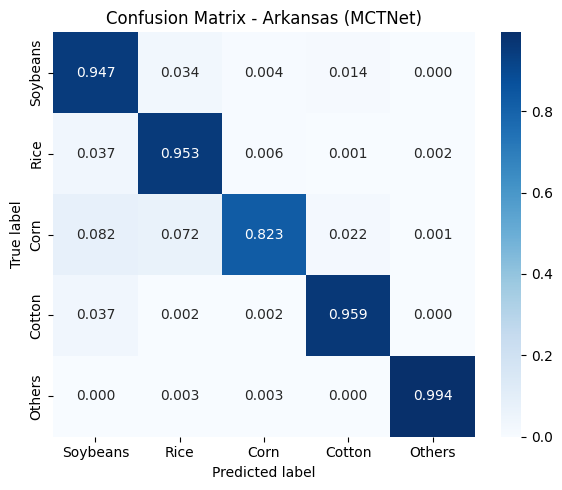

Generating California confusion matrix...


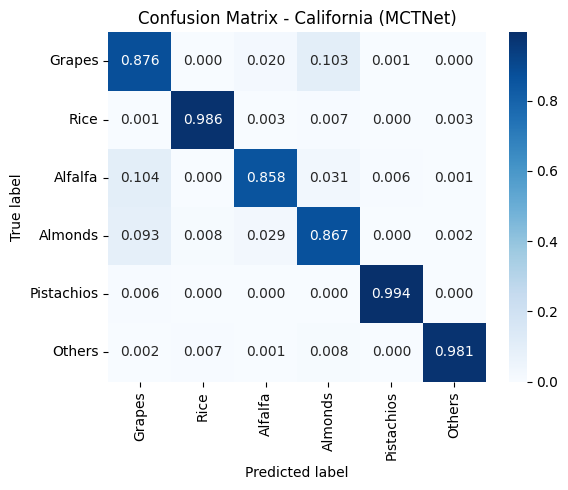

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import torch
from torch.utils.data import DataLoader

# ====================== ARKANSAS ======================
print("Generating Arkansas confusion matrix...")

# Use the existing Arkansas data + model
test_ds_ar = CropDataset(X_ar[te_ar], mask_ar[te_ar], y_ar[te_ar])
test_loader_ar = DataLoader(test_ds_ar, batch_size=256, shuffle=False, num_workers=0)

model_ar.to(device)
model_ar.eval()
all_preds_ar, all_labels_ar = [], []

with torch.no_grad():
    for X, mask, y in test_loader_ar:
        X, mask, y = X.to(device), mask.to(device), y.to(device)
        out = model_ar(X, mask)
        all_preds_ar.extend(out.argmax(1).cpu().numpy())
        all_labels_ar.extend(y.cpu().numpy())

cm_ar = confusion_matrix(all_labels_ar, all_preds_ar, normalize='true')

ar_classes = ['Soybeans', 'Rice', 'Corn', 'Cotton', 'Others']

plt.figure(figsize=(6, 5))
sns.heatmap(cm_ar, annot=True, fmt='.3f', cmap='Blues', 
            xticklabels=ar_classes, yticklabels=ar_classes, cbar=True)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix - Arkansas (MCTNet)')
plt.tight_layout()
plt.show()

# ====================== CALIFORNIA ======================
print("Generating California confusion matrix...")

test_ds_ca = CropDataset(X_ca[te_ca], mask_ca[te_ca], y_ca[te_ca])
test_loader_ca = DataLoader(test_ds_ca, batch_size=256, shuffle=False, num_workers=0)

model_ca.to(device)
model_ca.eval()
all_preds_ca, all_labels_ca = [], []

with torch.no_grad():
    for X, mask, y in test_loader_ca:
        X, mask, y = X.to(device), mask.to(device), y.to(device)
        out = model_ca(X, mask)
        all_preds_ca.extend(out.argmax(1).cpu().numpy())
        all_labels_ca.extend(y.cpu().numpy())

cm_ca = confusion_matrix(all_labels_ca, all_preds_ca, normalize='true')

ca_classes = ['Grapes', 'Rice', 'Alfalfa', 'Almonds', 'Pistachios', 'Others']

plt.figure(figsize=(6, 5))
sns.heatmap(cm_ca, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=ca_classes, yticklabels=ca_classes, cbar=True)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix - California (MCTNet)')
plt.tight_layout()
plt.show()

FINAL MODEL PERFORMANCE (Arkansas & California)

ARKANSAS:
  Test OA:    0.9333
  Test Kappa: 0.8971
  Test F1:    0.9275

CALIFORNIA:
  Test OA:    0.9437
  Test Kappa: 0.9247
  Test F1:    0.9133


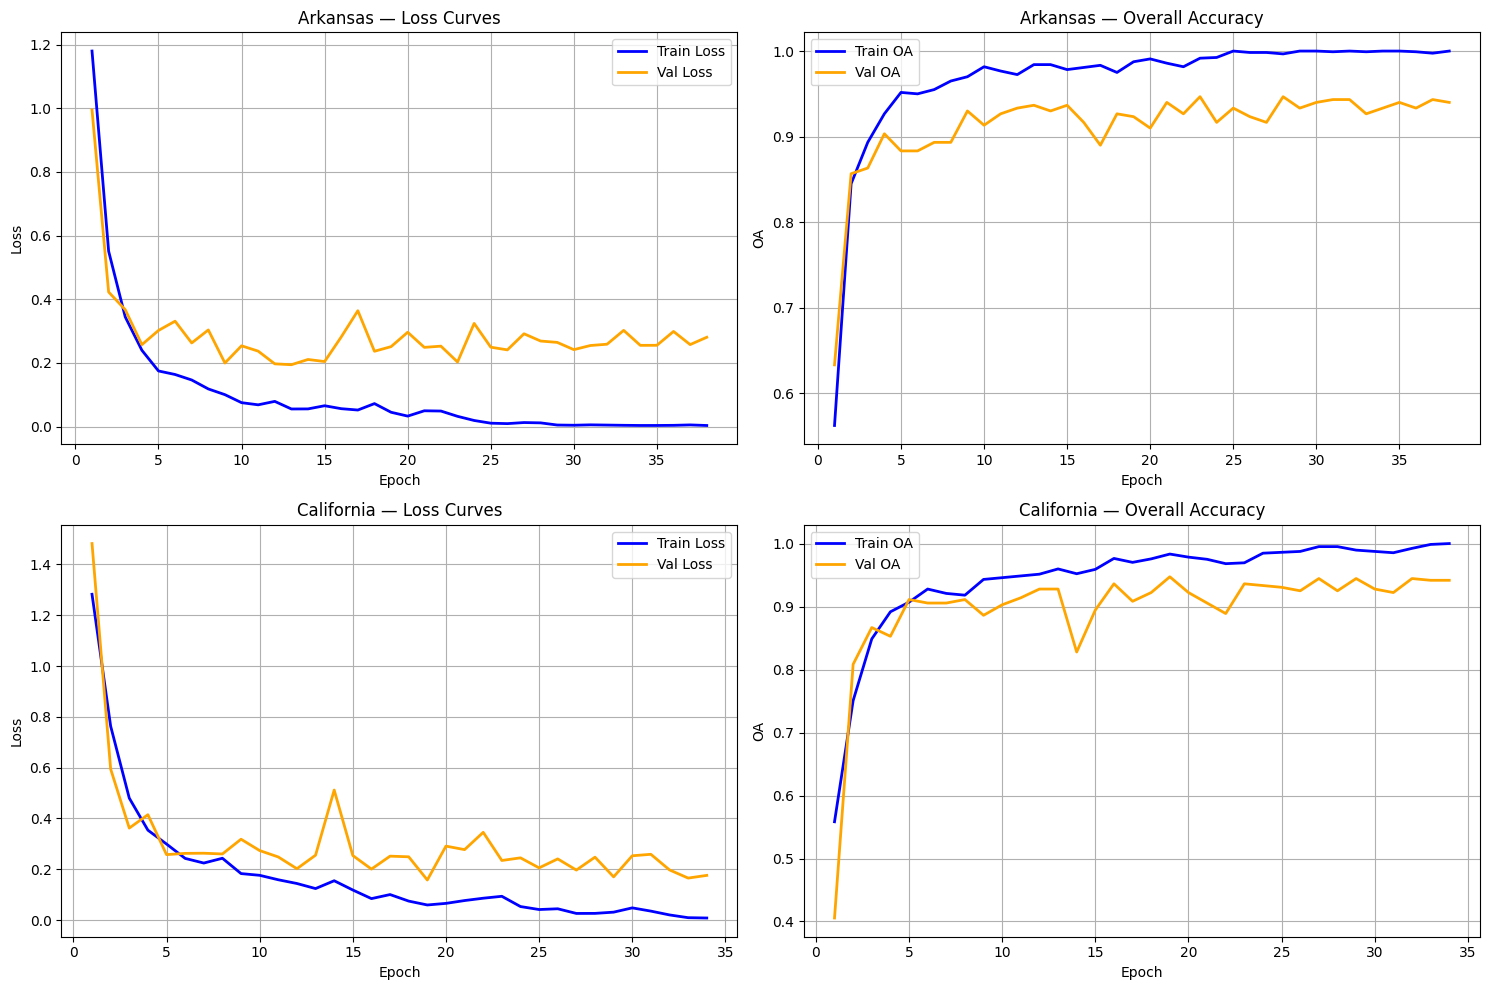


✅ Training curves saved as 'final_training_curves.png'


In [8]:
# ====================== FINAL PERFORMANCE SUMMARY ======================
print("="*80)
print("FINAL MODEL PERFORMANCE (Arkansas & California)")
print("="*80)

# Unpack results
test_oa_ar, test_kappa_ar, test_f1_ar = results_ar
test_oa_ca, test_kappa_ca, test_f1_ca = results_ca

print("\nARKANSAS:")
print(f"  Test OA:    {test_oa_ar:.4f}")
print(f"  Test Kappa: {test_kappa_ar:.4f}")
print(f"  Test F1:    {test_f1_ar:.4f}")

print("\nCALIFORNIA:")
print(f"  Test OA:    {test_oa_ca:.4f}")
print(f"  Test Kappa: {test_kappa_ca:.4f}")
print(f"  Test F1:    {test_f1_ca:.4f}")

# ====================== TRAINING CURVES ======================
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Arkansas Loss
axes[0,0].plot(hist_ar['epoch'], hist_ar['train_loss'], label='Train Loss', color='blue', linewidth=2)
axes[0,0].plot(hist_ar['epoch'], hist_ar['val_loss'], label='Val Loss', color='orange', linewidth=2)
axes[0,0].set_title('Arkansas — Loss Curves')
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Loss')
axes[0,0].legend()
axes[0,0].grid(True)

# Arkansas OA
axes[0,1].plot(hist_ar['epoch'], hist_ar['train_oa'], label='Train OA', color='blue', linewidth=2)
axes[0,1].plot(hist_ar['epoch'], hist_ar['val_oa'], label='Val OA', color='orange', linewidth=2)
axes[0,1].set_title('Arkansas — Overall Accuracy')
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('OA')
axes[0,1].legend()
axes[0,1].grid(True)

# California Loss
axes[1,0].plot(hist_ca['epoch'], hist_ca['train_loss'], label='Train Loss', color='blue', linewidth=2)
axes[1,0].plot(hist_ca['epoch'], hist_ca['val_loss'], label='Val Loss', color='orange', linewidth=2)
axes[1,0].set_title('California — Loss Curves')
axes[1,0].set_xlabel('Epoch')
axes[1,0].set_ylabel('Loss')
axes[1,0].legend()
axes[1,0].grid(True)

# California OA
axes[1,1].plot(hist_ca['epoch'], hist_ca['train_oa'], label='Train OA', color='blue', linewidth=2)
axes[1,1].plot(hist_ca['epoch'], hist_ca['val_oa'], label='Val OA', color='orange', linewidth=2)
axes[1,1].set_title('California — Overall Accuracy')
axes[1,1].set_xlabel('Epoch')
axes[1,1].set_ylabel('OA')
axes[1,1].legend()
axes[1,1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'final_training_curves.png'), dpi=200, bbox_inches='tight')
plt.show()

print("\n✅ Training curves saved as 'final_training_curves.png'")